# DataFrame
  - Series가 1차원이라면 DataFrame은 2차원으로 확대된 버젼
  - Excel spreadsheet이라고 생각하면 이해하기 쉬움
  - 2차원이기 때문에 인덱스가 row, column로 구성됨
   - row는 각 개별 데이터를, column은 개별 속성을 의미 ('feature' 라고도 함)
  - Data Analysis, Machine Learning에서 data 변형을 위해 가장 많이 사용

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import os
import math

In [3]:
# GoogleDriver mount 하고
base_path = r'/content/drive/MyDrive/KDT-2604/'


## read_csv()

In [4]:
filepath = os.path.join(base_path, 'titanic.csv')

In [5]:
# pd.read_csv() CSV 파일로부터 -> DataFrame 객체로 읽어오기
pd.read_csv(filepath)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
# 함수로 만들어 놓기
df = None
def load_titanic():
  return pd.read_csv(filepath)


In [7]:
df = load_titanic()
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [8]:
# 컬럼 의미
# survived - Survival (0 = No; 1 = Yes)
# class - Passenger Class (1 = 1st; 2 = 2nd; 3 = 3rd)
# name - Name
# sex - Sex
# age - Age
# sibsp - Number of Siblings/Spouses Aboard
# parch - Number of Parents/Children Aboard
# ticket - Ticket Number
# fare - Passenger Fare
# cabin - Cabin
# embarked - Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)
# boat - Lifeboat (if survived)
# body - Body number (if did not survive and body was recovered)

In [9]:
type(df)

pandas.core.frame.DataFrame

## head(), tail()
상위 n개, 하위n개 행만 보기 (기본값 5)

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [12]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## shape,describe(),info()
DataFrame 데이터 파악하기

 - shape 속성 (row, column)
 - describe 함수 - 숫자형 데이터의 통계치 계산  (descriptive statistics : 기술통계량)
 - info 함수 - 데이터 타입, 각 아이템의 개수 등 출력

In [13]:
df.shape

(891, 12)

In [14]:
df.info()

# 각 컬럼별 타입, 비어있지 않은 값의 개수

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
# 숫자형 데이터에 대해 기술통계량 정보
# count, mean, std : 개수, 평균, 표준편차
# max, min : 최대, 최소
# 25%, 50%, 75%  : 하위 4분위 하위 2분위...

df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 인덱스(index)
 - index 속성
 - 각 아이템을 특정할 수 있는 고유의 값을 저장
 - 복잡한 데이터의 경우, 멀티 인덱스로 표현 가능

In [17]:
df.index


RangeIndex(start=0, stop=891, step=1)

## 컬럼(column)
 - columns 속성
 - 각각의 특성(feature)을 나타냄
 - 복잡한 데이터의 경우, 멀티 컬럼으로 표현 가능

In [18]:

df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [19]:
# 컬럼, feature (특성), 속성, 필드, 차원...  <- 같은 말이다.

# DataFrame 생성하기

## list 로부터 DataFrame 생성
- list, tuple, array ... 와 같은 객체로부터 DataFrame 생성

In [20]:
df = pd.DataFrame([1, 2, 3])
df

,0
0,1
1,2
2,3


In [21]:
pd.DataFrame([
    '정준',  # 첫번째 행
    '희준',  # 두번째 행
    '태현',
])


,0
0,정준
1,희준
2,태현


In [22]:
df = pd.DataFrame([

    [1, 2, 3],  # 첫번째 행
    [4, 5, 6],  # 두번째 행
])

df

,0,1,2
0,1,2,3
1,4,5,6


## shape, ndim, size, len()

In [23]:
len(df)  # 행의 개수 axis-0 의 차원크기

2

In [24]:
df.shape

(2, 3)

In [25]:
df.ndim

2

In [26]:
df.size

6

In [27]:
df.dtype  # dtype 은 DataFrame 이 아닌 각 columne 마다 가지고 있다.

AttributeError: 'DataFrame' object has no attribute 'dtype'

In [ ]:
df.dtypes  # Series

## column, index 변경

In [ ]:
df2 = pd.DataFrame([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
], columns=['a', 'b', 'c', 'd'])

df2

In [ ]:
df2.columns

In [ ]:
# 컬럼 변경
df2.columns = ['국어', '영어', '수학', '과학']

df2

In [ ]:
df2.index

In [ ]:
# index 변경
df2.index = ['장희준', '김정준', '권용현']

df2


## dict 로 DataFrame 만들기

In [ ]:
data = {'a': [100], 'b': [200], 'c': [300]}  # value 가 1차원 데이터
# index= 없어도 생성됨!  (기본 0-base index)
pd.DataFrame(data)


In [ ]:
data = {'a': [100, 200, 300], 'b': ['cat', 'dog', 'bird'], 'c': [40, 50, 60]}
pd.DataFrame(data)


## '특정 컬럼' 의 이름 변경 rename()

In [ ]:
df2

In [ ]:
df2.rename(columns={'국어': 'kor', '과학': 'Sci'}, index={'권용현': '양정운'})


In [28]:
df2  # 원본 변경 없다!  inplace=

NameError: name 'df2' is not defined

## set_index(), reset_index()

In [29]:
df2

NameError: name 'df2' is not defined

In [30]:
df2.reset_index()

# 기존의 index 가 column 레벨로 올라오고
# 새로운 index 가 붙는다.

NameError: name 'df2' is not defined

In [31]:
# drop=True. 기존의 index 는 사라진다.
df2.reset_index(drop=True)


NameError: name 'df2' is not defined

In [32]:
df2

NameError: name 'df2' is not defined

In [33]:
# set_index(컬럼). 컬럼을 index 로 내리고,  기존의 인덱스를 대체한다.
df2.set_index('국어')


NameError: name 'df2' is not defined

In [34]:
df2

NameError: name 'df2' is not defined

In [35]:
# 퀴즈: df2 의 index 와 '국어' 컬럼을 바꾸려면?

# [결과]
# 	    index	  영어	수학	과학
# 국어
#  1	  고길동	  2	  3	    4
#  5	  둘리	    6	  7	    8
#  9    마이콜	 10	  11	  12

df2.reset_index().set_index('국어')



NameError: name 'df2' is not defined

## inplace=True
원본 변화 발생시키려면

In [36]:

df3 = df2

df3

NameError: name 'df2' is not defined

In [37]:
df3.set_index('국어', inplace=True)

NameError: name 'df3' is not defined

In [38]:
df3

NameError: name 'df3' is not defined

# Multi-level index, Multi-level column

In [39]:
pd.DataFrame({'k': [10]})

,k
0,10


In [40]:
pd.DataFrame({('k0', 'k1'): [10]})

,k0
,k1
0,10


In [41]:
pd.DataFrame({('k0', 'k1'): {'a': 10, 'b': 40}})

,k0
,k1
a,10
b,40


In [42]:
pd.DataFrame({('k0', 'k1'): {('a1', 'a2'): 10, ('b1', 'b2'): 40}})

,,k0
,,k1
a1,a2,10
b1,b2,40


In [43]:
df4 = pd.DataFrame(
    {
      ('k', 'k1') : [10, 20, 30, 31],
      ('k', 'k2') : [40, 50, 60, 61],
      ('j', 'j1') : [70, 80, 90, 91],
      ('j', 'j2') : [100, 110, 120, 121],
    },
    index=[['서울', '서울', '경기', '경기'], ['평일', '휴일', '평일', '휴일']]
)

df4

k       j     
       k1  k2  j1   j2
서울 평일  10  40  70  100
   휴일  20  50  80  110
경기 평일  30  60  90  120
   휴일  31  61  91  121

# column 선택하기
  - 기본적으로 [ ]는 column을 추출
  - 컬럼 인덱스일 경우 인덱스의 리스트 사용 가능
    - 리스트를 전달할 경우 결과는 Dataframe
    - 하나의 컬럼명을 전달할 경우 결과는 Series

In [44]:
df = load_titanic()

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 하나의 컬럼 선택

In [45]:
# df[0]  # 에러!  index 0 를 선택하는게 아니라,  column 0 를 선택.

In [46]:
df['Survived']   # Series

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [47]:
df.Survived   # 위와 동일한 결과

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [48]:
df.Age

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


## 복수의 컬럼 선택하기

In [49]:
# list 형태로 컬럼 선택

In [50]:
df['Survived']  # 결과 Series (1차원)


,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [51]:
df[['Survived']]  # 결과 DataFrame ⭐️  (2차원)


,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [52]:
df[['Survived', 'Age', 'Name', 'Survived']]


,Survived,Age,Name,Survived
0,0,22.0,"Braund, Mr. Owen Harris",0
1,1,38.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1
2,1,26.0,"Heikkinen, Miss. Laina",1
3,1,35.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1
4,0,35.0,"Allen, Mr. William Henry",0
...,...,...,...,...
886,0,27.0,"Montvila, Rev. Juozas",0
887,1,19.0,"Graham, Miss. Margaret Edith",1
888,0,NaN,"Johnston, Miss. Catherine Helen ""Carrie""",0
889,1,26.0,"Behr, Mr. Karl Howell",1


# row 선택하기

## loc[], iloc[]
  - Series의 경우 []로 row 선택이 가능하나, **DataFrame의 경우는 기본적으로 column을 선택하도록 설계**
  - `.loc[]`, `.iloc[]`로 row 선택 가능
    - loc - 인덱스 자체를 사용
    - iloc - 0 based index로 사용
    - 위 두가지는 `,` 를 사용하여 column 선택도 가능

In [53]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [54]:
# index 변경 (예제 이해를 돕기 위해)
df.index += 100

df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
986,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
987,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
988,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
989,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
990,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### loc[index]

In [55]:
df.loc[986]  # Series   컬럼 dtype 이 제각각 인 경우 object 로 통일.

,986
PassengerId,887
Survived,0
Pclass,2
Name,"Montvila, Rev. Juozas"
Sex,male
Age,27.0
SibSp,0
Parch,0
Ticket,211536
Fare,13.0


In [56]:
df.loc[[986]]  # DataFrame

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
986,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0,NaN,S


In [57]:
df.loc[[986, 100, 110, 990]]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
986,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
100,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
110,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.70,G6,S
990,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### iloc[0-base]

In [58]:
# df.loc[0]  # 에러  0 이라는 인덱스 없다

In [59]:
df.iloc[0]   # 0번 index 가 아니라 0번째 row.  Series

,100
PassengerId,1
Survived,0
Pclass,3
Name,"Braund, Mr. Owen Harris"
Sex,male
Age,22.0
SibSp,1
Parch,0
Ticket,A/5 21171
Fare,7.25


In [60]:
df.iloc[[0]]  # DataFrame

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
100,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [61]:
df.iloc[[0, 100, 200, 2]]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
100,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
200,101,0,3,"Petranec, Miss. Matilda",female,28.0,0,0,349245,7.8958,NaN,S
300,201,0,3,"Vande Walle, Mr. Nestor Cyriel",male,28.0,0,0,345770,9.5000,NaN,S
102,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## row, column 동시에 선택하기
loc[], iloc[] 속성을 이용할때  tuple을  사용하여 row, column 둘다 명시 가능

In [62]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
986,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
987,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
988,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
989,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
990,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [63]:
# loc[row, column] <- loc[axis0, axis1]
df.loc[986, 'Survived']


np.int64(0)

In [64]:
# iloc[0 base row, 0 base column]
df.iloc[-5, -3]


np.float64(13.0)

In [65]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
100,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
101,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
102,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
103,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
104,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [66]:
# iloc[0 base row, 0 base column]
df.iloc[2, 3]

'Heikkinen, Miss. Laina'

In [67]:
df.loc[102, 'Name']

'Heikkinen, Miss. Laina'

In [68]:
df['Name'][102]

'Heikkinen, Miss. Laina'

In [69]:
df.loc[102]['Name']

'Heikkinen, Miss. Laina'

In [70]:
df.loc[[102, 986, 100, 110], ['Name', 'Survived', 'Sex', 'Age']]

,Name,Survived,Sex,Age
102,"Heikkinen, Miss. Laina",1,female,26.0
986,"Montvila, Rev. Juozas",0,male,27.0
100,"Braund, Mr. Owen Harris",0,male,22.0
110,"Sandstrom, Miss. Marguerite Rut",1,female,4.0


# boolean selection으로 row 선택하기
 - numpy에서와 동일한 방식으로 해당 조건에 맞는 row만 선택

In [71]:
# 나이 30대 이면서 1등객실에 탑승한 승객들 선택

In [72]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
100,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
101,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
102,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
103,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
104,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [73]:
df.Pclass

,Pclass
100,3
101,1
102,3
103,1
104,3
...,...
986,2
987,1
988,3
989,1


In [74]:
# unique()
df.Pclass.unique()

array([3, 1, 2])

In [75]:
# value_counts()
df.Pclass.value_counts()

,count
Pclass,
3,491
1,216
2,184


In [76]:
pclass_mask = df['Pclass'] == 1
pclass_mask

,Pclass
100,False
101,True
102,False
103,True
104,False
...,...
986,False
987,True
988,False
989,True


In [77]:
# 위 boolean mask 를 DataFrame 에 인덱싱
df[pclass_mask]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
101,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
103,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
106,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
111,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
123,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S
...,...,...,...,...,...,...,...,...,...,...,...,...
971,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
972,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
979,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
987,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [78]:
# 30대 승객에 대한 boolean mask
age_mask = (df.Age >= 30) & (df.Age < 40)
age_mask

,Age
100,False
101,True
102,False
103,True
104,True
...,...
986,False
987,False
988,False
989,False


In [79]:
df[age_mask]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
101,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
103,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
104,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
113,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
118,19,0,3,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,1,0,345763,18.0000,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
967,868,0,1,"Roebling, Mr. Washington Augustus II",male,31.0,0,0,PC 17590,50.4958,A24,S
972,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
981,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
985,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q


In [80]:
df[age_mask & pclass_mask]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
101,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
103,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
161,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0000,B28,NaN
237,138,0,1,"Futrelle, Mr. Jacques Heath",male,37.0,1,0,113803,53.1000,C123,S
315,216,1,1,"Newell, Miss. Madeleine",female,31.0,1,0,35273,113.2750,D36,C
318,219,1,1,"Bazzani, Miss. Albina",female,32.0,0,0,11813,76.2917,D15,C
324,225,1,1,"Hoyt, Mr. Frederick Maxfield",male,38.0,1,0,19943,90.0000,C93,S
330,231,1,1,"Harris, Mrs. Henry Birkhardt (Irene Wallach)",female,35.0,1,0,36973,83.4750,C83,S
348,249,1,1,"Beckwith, Mr. Richard Leonard",male,37.0,1,1,11751,52.5542,D35,S
357,258,1,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.5000,B77,S


In [81]:
df[age_mask & pclass_mask][['Pclass', 'Age']]

,Pclass,Age
101,1,38.0
103,1,35.0
161,1,38.0
237,1,37.0
315,1,31.0
318,1,32.0
324,1,38.0
330,1,35.0
348,1,37.0
357,1,30.0


### 도전] 3등급 객실의 생존자 수는?

> 결과 119명


In [82]:
# True  는 1 로 계산된다!
pclass_mask = df['Pclass'] == 3
df[pclass_mask][['Survived']].sum()

,0
Survived,119


In [83]:
# Survived 는 1, 0  의 값만 가지고 있을테니
# 🔹TODO

### 도전] 남성과 여성의 생존률은 ?

> [결과 예시]<br>
> 남성생존률 0.18890814558058924<br>
> 여성생존률 0.7420382165605095


In [84]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
100,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
101,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
102,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
103,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
104,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [85]:
df[df['Sex'] == 'male'][['Survived']].mean()

,0
Survived,0.188908


In [86]:
df[df['Sex'] != 'male'][['Survived']].mean()

,0
Survived,0.742038


In [87]:
df.loc[:, 'Sex']

,Sex
100,male
101,female
102,female
103,female
104,male
...,...
986,male
987,female
988,female
989,male


In [88]:
df.Sex.unique()

array(['male', 'female'], dtype=object)

In [89]:
df.Sex.value_counts()

,count
Sex,
male,577
female,314


# row, column 추가, 삭제

## column 추가하기
- `[ ]` 사용하여 추가하기
- insert() 사용하여 원하는 위치에 추가

In [90]:
df['Name']

,Name
100,"Braund, Mr. Owen Harris"
101,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
102,"Heikkinen, Miss. Laina"
103,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
104,"Allen, Mr. William Henry"
...,...
986,"Montvila, Rev. Juozas"
987,"Graham, Miss. Margaret Edith"
988,"Johnston, Miss. Catherine Helen ""Carrie"""
989,"Behr, Mr. Karl Howell"


In [91]:
# KeyError
df['Age_Double']

KeyError: 'Age_Double'

In [92]:
df['Age'] * 2

,Age
100,44.0
101,76.0
102,52.0
103,70.0
104,70.0
...,...
986,54.0
987,38.0
988,NaN
989,52.0


In [93]:
# 위 결과를 df 의 새로운 컬럼으로 추가
df['Age_Double'] = df['Age'] * 2

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Double
100,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,44.0
101,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,76.0
102,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,52.0
103,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,70.0
104,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,54.0
987,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,38.0
988,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN
989,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,52.0


**파생변수**

기존에 존재하는 속성(변수, 컬럼) 으로부터 새로운 속성(컬럼) 을 만들어 낸것.

## insert()
원하는 위치에 컬럼 추가

In [94]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Double
100,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,44.0
101,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,76.0
102,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,52.0
103,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,70.0
104,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,70.0


In [95]:
df['Fare'] / 10

,Fare
100,0.72500
101,7.12833
102,0.79250
103,5.31000
104,0.80500
...,...
986,1.30000
987,3.00000
988,2.34500
989,3.00000


In [96]:
# 컬럼 인덱스 3 위치에 'Fare10' 이라는 새로운 컬럼 삽입
df.insert(3, 'Fare10', df['Fare'] / 10)
df.head()

,PassengerId,Survived,Pclass,Fare10,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Double
100,1,0,3,0.72500,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,44.0
101,2,1,1,7.12833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,76.0
102,3,1,3,0.79250,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,52.0
103,4,1,1,5.31000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,70.0
104,5,0,3,0.80500,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,70.0


## column 삭제하기
 - drop 함수 사용하여 삭제
   - axis= 사용
   - 리스트를 사용하여 멀티플 삭제 가능

In [97]:
# DataFrame 은 2차원 데이터,  axis= 값은 0, 1 두가지가 존재 한다
# axis=0 : row level  (default)
# axis=1 : column level

In [98]:
# df.drop('Age_Double')

In [99]:
# 열 제거, 원본 변화 없다.
df.drop('Age_Double', axis=1)


,PassengerId,Survived,Pclass,Fare10,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
100,1,0,3,0.72500,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
101,2,1,1,7.12833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
102,3,1,3,0.79250,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
103,4,1,1,5.31000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
104,5,0,3,0.80500,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,887,0,2,1.30000,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
987,888,1,1,3.00000,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
988,889,0,3,2.34500,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
989,890,1,1,3.00000,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [100]:
# 원본 변화 주려면 inplace=True
df.drop('Age_Double', axis=1, inplace=True)


In [101]:
df.head()

,PassengerId,Survived,Pclass,Fare10,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
100,1,0,3,0.72500,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
101,2,1,1,7.12833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
102,3,1,3,0.79250,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
103,4,1,1,5.31000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
104,5,0,3,0.80500,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 행 (row) 추가 삭제
- 추가 loc[]
- 삭제 drop()

In [102]:
df2 = pd.DataFrame([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
], columns=['a','b','c','d'], index = ['김길동', '최진수', '허수민'])
df2

,a,b,c,d
김길동,1,2,3,4
최진수,5,6,7,8
허수민,9,10,11,12


In [103]:
# 새로운 행(row) 추가
df2.loc['김정준'] = pd.Series([100, 200, 300, 400], index=['a', 'b', 'c', 'd'])

df2

,a,b,c,d
김길동,1,2,3,4
최진수,5,6,7,8
허수민,9,10,11,12
김정준,100,200,300,400


In [104]:
df2.loc['장희준'] = [100, 200, 300, 400]

df2

,a,b,c,d
김길동,1,2,3,4
최진수,5,6,7,8
허수민,9,10,11,12
김정준,100,200,300,400
장희준,100,200,300,400


In [105]:
# 행 삭제
# drop() 사용,   axis=0 (디폴트)
df2.drop(['김정준', '장희준'])


,a,b,c,d
김길동,1,2,3,4
최진수,5,6,7,8
허수민,9,10,11,12


## 행 삽입

In [106]:
# df.insert?  <- column만 insert하는 함수

In [107]:
# 방법 1: pd.concat() + iloc[:]

In [108]:
df2.iloc[:2]

,a,b,c,d
김길동,1,2,3,4
최진수,5,6,7,8


In [109]:
df2.iloc[:2]

,a,b,c,d
김길동,1,2,3,4
최진수,5,6,7,8


In [110]:
pd.concat([
    df2.iloc[:2],
    df2.iloc[2:],
])

,a,b,c,d
김길동,1,2,3,4
최진수,5,6,7,8
허수민,9,10,11,12
김정준,100,200,300,400
장희준,100,200,300,400


In [111]:
pd.concat([
    df2.iloc[:2],
    pd.DataFrame({'a': 10, 'b': 20, 'c': 30, 'd': 40}, index=['신하석']),
    df2.iloc[2:],
])

,a,b,c,d
김길동,1,2,3,4
최진수,5,6,7,8
신하석,10,20,30,40
허수민,9,10,11,12
김정준,100,200,300,400
장희준,100,200,300,400


In [112]:
# 방법2 transpose + insert()

df_t = df2.T
df_t.insert(2, '신하석', [10, 20, 30, 40])
df_t.T

,a,b,c,d
김길동,1,2,3,4
최진수,5,6,7,8
신하석,10,20,30,40
허수민,9,10,11,12
김정준,100,200,300,400
장희준,100,200,300,400


# Correlation : 상관관계

In [113]:
# ※ 컬럼, 속성, 변수, 특징(feature), 차원<- 정형데이터에선 다 똑같은 말.

# 상관관계 (correlation)
# 특정한 '값' 과의 상관관계,  두 변수간의 흐름이 얼마나 비슷한 가를 나타내는 척도
#                           두 변수간의 흐름이 어떤 선형적(linear) 한 관계를 나타내는 척도

# 가령
#   a 값이 증가할때 b 값도 증가하나?(혹은 감소하나?).
#  증감의 성향은 어떠한가?  <-- 데이터의 분포, 추세를 보는데 중요

# -1 ~ +1 사이로 표현한다
# +1 에 가까울수록 a, b  둘이 비슷하게 증감 한다.
# -1 에 가까울수록 a, b 증감은 반대로 진행 한다.
# 절대값이 클수록 관계가 크다 라고 볼수 있다.

# 절대값 0에 가까우면 상관관계가 작다

# 그러나
# +1 에 가깝다고 해서 이것이 '인과관계' 를 나타내는 것은 아니다. (일수도, 아닐수도 있는것.)


# 통계학자들은 '상관계수'라는 것을 만들었다. 여러 가지 고안된 방법이 있으며,
# 대표적으로 피어슨 상관계수(Pearson Correlation Coefficient, Pearson's r),
# 스피어만 상관계수(Spearman Correlation Coefficient), 크론바흐의 알파(Cronbach's Alpha)가 있다.
# 이 중 피어슨 상관계수가 압도적으로 많이 사용된다

## 변수(column) 사이의 상관계수(correlation)
 - corr() 함수를 통해 상관계수 연산 (-1, 1 사이의 결과)
   - 연속성(숫자형)데이터에 대해서만 연산
   - 인과관계를 의미하진 않음


In [114]:
df = load_titanic()

In [115]:
df.corr(numeric_only=True)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [116]:
# 절대값이 높다 -> 상관관계가 높다.
# 어떤 컬럼들이 상관관계가 높나?

#
# Fare - Pclass
# Survived - Pclass
# Survived - Fare
# Age - Pclass
# parch-SibSp
# SibSp-Age

In [117]:
import matplotlib.pyplot as plt

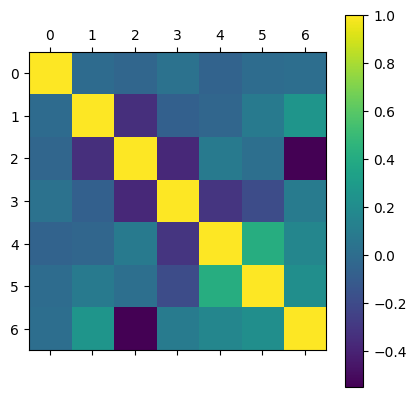

In [118]:
# 상관관계 시각화
plt.matshow(df.corr(numeric_only=True))
plt.colorbar()
plt.show()


# NaN 처리

In [119]:
# NaN : Not a Number  <-- '결측값(missing value)' 이라고도 한다
#    (NA: Not Available 라고도 표기하며  np.NaN, None 등이 해당한다)
# 여러가지 이유에 의해 데이터 안에 결측값이 존재할수 있다. (누락, 소실 등...)

# 값이 0 이라는 뜻이 아니다!  값이 '없다'는 뜻이다.

# 데이터 분석 이전에 반드시 NaN 값 존재 여부도 확인해야 한다

# 데이터 분석시 '전처리' 단계에서 NaN 값에 대한 적절한 전처리를 해주어야.
# 정확한 분석과 인공지능 학습을 기대할수 있다.

# 일반적으로 두가지 방법 사용하여 NaN 처리
#  1. 결측값은 무시하든지
#  2. 다른값으로 채우든지


## NaN 값 확인
 - describe, info함수를 통하여 개수 확인
 - isna함수를 통해 boolean 타입으로 확인

In [120]:
df.info()
# ↓ Age, Cabin, Embarked 는 결측치가 있슴을 알수 있다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [121]:
df.isna()

# ↓ 결측치는 True 로 표시된다.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [122]:
# 특정 컬럼에 대해서 확인
df['Age'].isna()


,Age
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,True
889,False


In [123]:
# 결측된 데이터만 확인 <- boolean selection 활용
df[df['Age'].isna()]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


## NaN 삭제
 - 데이터에서 삭제
   - dropna 함수

In [124]:
print(df.shape)  # 891 row

df.dropna()  # 183 row

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [125]:
# ↑ 183개의 row 가 나온다 (891개에서 확 줄었다)
# index 나 PassengerId 를 보면 중간중간에 빠진거 확인


# dropna() 기본적으로 row 기준(axis=0)으로 동작한다
# 각 row 에서, 하나라도 NaN 값이 있으면 해당 row 를 지워버린다

In [126]:
# 행을 삭제하되, 특정 컬럼에 대해서만 dropna 하기

df.dropna(subset=['Age'])  # 714 row

# ↓Age 컬럼이 NaN 인 경우만 row 가 drop 됨 (axis=0)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [127]:
df.dropna(subset=['Age', 'Cabin'])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [128]:
# NaN 이 있는 '컬럼' 삭제하기
df.dropna(axis=1)

#  ↓ Age, Cabin, Embarked 컬럼 삭제!

,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare
0,1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,7.2500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,71.2833
2,3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,7.9250
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,53.1000
4,5,0,3,"Allen, Mr. William Henry",male,0,0,373450,8.0500
...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,0,0,211536,13.0000
887,888,1,1,"Graham, Miss. Margaret Edith",female,0,0,112053,30.0000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,1,2,W./C. 6607,23.4500
889,890,1,1,"Behr, Mr. Karl Howell",male,0,0,111369,30.0000


## NaN 값 대체하기
 - fillna()
 - ex)평균으로 대체하기
 - ex) 생존자/사망자 별 평균으로 대체하기

In [129]:
# Age 평균값
df['Age'].mean()  # NaN 은 배제된 연산결과닷! 주의

np.float64(29.69911764705882)

In [130]:
df['Age'].count()

np.int64(714)

In [131]:
# 위 mean() 값은 891명에 대한 평균값이 아니라 714 명에 대한 평균값이다

df['Age'].sum() / df['Age'].count()


np.float64(29.69911764705882)

In [132]:
# NaN 을 평균값으로 대체
df['Age'].fillna(df['Age'].mean())


,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [133]:
df.tail()  # 위 결과로 원본이 변경된거 아니다.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


## 도전] Age NaN 값을 생존자/사망자 별 평균으로 대체하기

In [134]:
# 생존자의 나이 평균
live = df[df['Survived'] == 1]['Age'].mean()


In [135]:
# 사망자의 나이 평균
ded = df[df['Survived'] == 0]['Age'].mean()

In [136]:
# 생존자/사망자 별 평균값을 NaN에 채워 넣기
df.loc[df['Survived'] == 1, 'Age'] = df[df['Survived'] == 1]['Age'].fillna(live)
df.loc[df['Survived'] == 0, 'Age'] = df[df['Survived'] == 0]['Age'].fillna(ded)

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [138]:
df[df['Survived'] == 1]['Age'].fillna(mean1, inplace=True)  # 사본에 대해 inplace=True 옵션 주면 warning

NameError: name 'mean1' is not defined

# 수치형(numerical) & 범주형(categorical) 데이터의 이해
 - dtype 에 대한 이야기가 아니다!

In [139]:
# info() 함수로 dtype 확인
df.info()

# 숫자형은 int64.. float64..
# 문자형은 object...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [140]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


## 수치형(Numerical Type) 데이터
 - 연속성을 띄는 숫자로 이루어진 데이터
   - 예) Age, Fare 등
 - 대소비교, 산술연산 (평균, 합계, 중간값) 의미있슴

## 범주형(Categorical Type) 데이터 (aka 분류형 데이터)
 - 연속적이지 않은 값(대부분의 경우 숫자를 제외한 나머지 값)을 갖는 데이터를 의미
   - 예) Name, Sex, Ticket, Cabin, Embarked
 - 어떤 경우, 데이터타입(dtype)이 숫자형 타입이라 할지라도 개념적으로 범주형으로 처리해야할 경우가 있음
   - 예) Pclass, Survived   
 - 대소비교, 산술연산(평균, 합계, 중간값...) 의미없슴

In [141]:
# Age 를 생각해보자
#  대소비교 가능한가 : OK
#  평균값 (연산) 의미 있나 : ex) 탑승객의 평균 나이.  OK
#  나이 40 = 나이 20 x 2
#  연속성을 띄고 있나? : OK

# 따라서 '수치형' 으로 다루면 된다.

In [142]:
# Pclass 은 어떠한가 . 일단 이것도 dtype int64 타입이긴 한데.  그러면 수치형인가?

# 이들의 대소 관계 비교가 의미 있나?    1등급 < 3등급  ???
# 평균값은 의미 있나?   승객들의 객실등급 평균은 2.308641975308642  입니다.
#     3등급 객실 = 1등급 객실 x 3   ????  <-- 의미 없는 연산

# 연속성도 없다.  1.1등급? 1.7등급?

# 이는 단순히 1등급, 2등급, 3등급 이란 '범주(category)' 를 나타내는 (구별하기 위한) 데이터 이다.

In [143]:
# 대한민국 우편번호는 '숫자' 로 이루어져 있다
# 이는 '수치형?'   '범주형?'

# 역삼동 06240
# 제주시 애월읍 63131

# 애월읍은 역삼동의 약 10.11 배 입니다 <-- 의미 있나?

## Age 변수 변환
- apply(func) 함수 활용

In [144]:
# 10대, 20대, 30대...  <-- 수치형? 분류형?

In [145]:
# 가령
# Age 값이 너무 세분화(?) 되어 있어 보인다.?
# 그래서 이렇게 해볼수 있습니다.

# 10대, 20대, 30대..   <-- 이런식으로 '분류(Categorical)' 하는 식으로 변환해볼수도 있을겁니다.

# 22.0 23.0 ,.. ==> '20대' 로 분류
# 30.0 31.0 32.0 ... ==> '30대' 로 분류

# 위와 같이 '숫자형' 데이터를 다시 '분류형Category' 으로 만들어 보고 싶을수도 있습니다.

### apply(func) 함수
- 변환로직 func 을 적용

In [146]:
# 23 -> 20
# 43 -> 40
def age_categorize(age):
  if math.isnan(age):
    return -1

  return int(age / 10) * 10

In [147]:
age_categorize(23)

20

In [148]:
# 특정 컬럼에 apply(함수) 한다
age_span = df['Age'].apply(age_categorize)
age_span

,Age
0,20
1,30
2,20
3,30
4,30
...,...
886,20
887,10
888,30
889,20


In [149]:
# 분류형의 경우 확인해보자.
age_span.unique()

array([20, 30, 50,  0, 10, 40, 60, 70, 80])

In [150]:
age_span.value_counts()

,count
Age,
30,292
20,272
10,102
40,89
0,62
50,48
60,19
70,6
80,1


In [151]:
# 위 범주형 데이터를 df 에 추가 (파생변수 추가)
df['Age_span'] = age_span
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_span
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S,20
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,30
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S,20
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,30
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S,20
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S,10
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,30.626179,1,2,W./C. 6607,23.4500,NaN,S,30
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C,20


In [152]:
df[['Age', 'Age_span']]

,Age,Age_span
0,22.000000,20
1,38.000000,30
2,26.000000,20
3,35.000000,30
4,35.000000,30
...,...,...
886,27.000000,20
887,19.000000,10
888,30.626179,30
889,26.000000,20


## One-hot encoding
범주형(categorical) 데이터 전처리

In [153]:
# "Red", "Green", "Blue"

In [154]:
# 범주형 데이터는 연산이 불가하다 (혹은 의미 없다)
# 그래서 '처리' 가 가능하도록 데이터를 바꿔주어야 할 필요가 있다.  (????)

# 범주형 테이터 컬럼한개를 '범주의 개수' 만큼 늘려서
# 범주에 해당하는 값에만 '1' 을 주고
# 나머지에는 '0' 을 주어 처리하는 방법
# --> 이를 One-hot encoding 이라 합니다  <-- 결국 '1' 은 한개만 등장한다

# 가령
# Color 란 컬럼에  "Red", "Green", "Blue"  라는 '세가지' 종류의 범주값만 있다면

# '세 개'의 '0, 1 로 구성된 값'으로 변환시키는 겁니다 ('1' 은 한개만 등장)
#   Red ->   [1, 0, 0]
#   Green -> [0, 1, 0]
#   Blue ->  [0, 0, 1]

 - 범주형 데이터는 분석단계에서 계산이 어렵기 때문에 숫자형으로 변경이 필요함
 - 범주형 데이터의 각 범주(category)를 column레벨로 변경
 - 해당 범주에 해당하면 1, 아니면 0으로 채우는 인코딩 기법
 - pandas.get_dummies 함수 사용
   - drop_first : 첫번째 카테고리 값은 사용하지 않음
   - dtype=int : True/False 대신 1/0 으로 변환

In [155]:
df['Pclass'].unique()

array([3, 1, 2])

In [156]:
pd.get_dummies(df)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age_span,"Name_Abbing, Mr. Anthony","Name_Abbott, Mr. Rossmore Edward",...,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.000000,1,0,7.2500,20,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2,1,1,38.000000,1,0,71.2833,30,False,False,...,False,False,False,False,False,False,False,True,False,False
2,3,1,3,26.000000,0,0,7.9250,20,False,False,...,False,False,False,False,False,False,False,False,False,True
3,4,1,1,35.000000,1,0,53.1000,30,False,False,...,False,False,False,False,False,False,False,False,False,True
4,5,0,3,35.000000,0,0,8.0500,30,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000,20,False,False,...,False,False,False,False,False,False,False,False,False,True
887,888,1,1,19.000000,0,0,30.0000,10,False,False,...,False,False,False,False,False,False,False,False,False,True
888,889,0,3,30.626179,1,2,23.4500,30,False,False,...,False,False,False,False,False,False,False,False,False,True
889,890,1,1,26.000000,0,0,30.0000,20,False,False,...,False,False,False,False,False,False,False,True,False,False


In [157]:
# columns=  파라미터로
# one-hot encoding 컬럼으로 만들어질 컬럼들을 지정해줄수 있다.

pd.get_dummies(df, columns=['Pclass', 'Sex', 'Embarked'], dtype=int)

# dtype=int  를 주면, 0 과 1 로 인코딩된다.

,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Age_span,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,"Braund, Mr. Owen Harris",22.000000,1,0,A/5 21171,7.2500,NaN,20,0,0,1,0,1,0,0,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.000000,1,0,PC 17599,71.2833,C85,30,1,0,0,1,0,1,0,0
2,3,1,"Heikkinen, Miss. Laina",26.000000,0,0,STON/O2. 3101282,7.9250,NaN,20,0,0,1,1,0,0,0,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.000000,1,0,113803,53.1000,C123,30,1,0,0,1,0,0,0,1
4,5,0,"Allen, Mr. William Henry",35.000000,0,0,373450,8.0500,NaN,30,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,"Montvila, Rev. Juozas",27.000000,0,0,211536,13.0000,NaN,20,0,1,0,0,1,0,0,1
887,888,1,"Graham, Miss. Margaret Edith",19.000000,0,0,112053,30.0000,B42,10,1,0,0,1,0,0,0,1
888,889,0,"Johnston, Miss. Catherine Helen ""Carrie""",30.626179,1,2,W./C. 6607,23.4500,NaN,30,0,0,1,1,0,0,0,1
889,890,1,"Behr, Mr. Karl Howell",26.000000,0,0,111369,30.0000,C148,20,1,0,0,0,1,1,0,0


In [158]:
# drop_first=True
pd.get_dummies(df, columns=['Pclass', 'Sex', 'Embarked'], dtype=int, drop_first=True)


,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Age_span,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,1,0,"Braund, Mr. Owen Harris",22.000000,1,0,A/5 21171,7.2500,NaN,20,0,1,1,0,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.000000,1,0,PC 17599,71.2833,C85,30,0,0,0,0,0
2,3,1,"Heikkinen, Miss. Laina",26.000000,0,0,STON/O2. 3101282,7.9250,NaN,20,0,1,0,0,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.000000,1,0,113803,53.1000,C123,30,0,0,0,0,1
4,5,0,"Allen, Mr. William Henry",35.000000,0,0,373450,8.0500,NaN,30,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,"Montvila, Rev. Juozas",27.000000,0,0,211536,13.0000,NaN,20,1,0,1,0,1
887,888,1,"Graham, Miss. Margaret Edith",19.000000,0,0,112053,30.0000,B42,10,0,0,0,0,1
888,889,0,"Johnston, Miss. Catherine Helen ""Carrie""",30.626179,1,2,W./C. 6607,23.4500,NaN,30,0,1,0,0,1
889,890,1,"Behr, Mr. Karl Howell",26.000000,0,0,111369,30.0000,C148,20,0,0,1,0,0


In [159]:
# 이렇게 one-hot encoding 함으로,
# 범주형 데이터도 '연산'이 가능한 형태로 바뀌었다.
# 도대체 '연산'이 무엇이기에?

# 머신러닝등을 하다보면 범주형 데이터에 대한 예측값이 정확히 [1, 0, 0] 이런식으로 나오지 않는다
# 수~~~ 많은 '연산'을 통해  [0.98232424,  0.0003455, 0.000455] <-- 이런식으로 나온다.

# [0.98232424,  0.0003455, 0.000455] 은 다음 세개중 무엇에 가장 가까운가?
#    [1, 0, 0]
#    [0, 1, 0]
#    [0, 0, 1]
# 이 판단 과정도 산술 '연산'인 것이다.

# 이것이 바로 '연산' 이 가능한 형태라는 의미다.

# groupby
  + 데이터를 특정 조건(ex:컬럼..)으로 묶어서 그룹화
  + 아래의 세 단계를 적용하여 데이터를 그룹화(groupping) (SQL의 group by 와 개념적으로는 동일, 사용법은 유사)
    - 데이터 분할 (split)
    - operation 적용 (apply)
    - 데이터 병합 (combine)
    

In [160]:
df = load_titanic()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## groupby(by=),  groups 속성
 - 각 그룹과 그룹에 속한 index를 dict 형태로 표현

In [161]:
# groupby(by=컬럼 혹은 컬럼의 리스트)

In [162]:
grouped_pclass = df.groupby('Pclass')
grouped_pclass

# DataFrameGroupBy 객체 (이하 'groupby 객체' 라 하겠습니다)

In [163]:
# groupby 객체의 속성
#   - groups -> dict 형태
#   - key -> 컬럼의 각 값
#   - value -> 인덱스 값들의 list

In [164]:
# Pclass 의 값은 1, 2, 3 세 개 밖에 없었으니 그룹 개수는 3개다
grouped_pclass.groups

# DataFrameGroupBy 객체 (이하 'groupby 객체' 라 하겠습니다)# 🔹TODO

# groups 의 key 값은 'Pclass' 의 값들,
#          value 는 index 들의 list

{1: [1, 3, 6, 11, 23, 27, 30, 31, 34, 35, 52, 54, 55, 61, 62, 64, 83, 88, 92, 96, 97, 102, 110, 118, 124, 136, 137, 139, 151, 155, 166, 168, 170, 174, 177, 185, 187, 194, 195, 209, 215, 218, 224, 230, 245, 248, 252, 256, 257, 258, 262, 263, 268, 269, 270, 273, 275, 284, 290, 291, 295, 297, 298, 299, 305, 306, 307, 309, 310, 311, 318, 319, 325, 329, 331, 332, 334, 336, 337, 339, 341, 351, 356, 366, 369, 370, 373, 375, 377, 380, 383, 390, 393, 412, 430, 434, 435, 438, 445, 447, ...], 2: [9, 15, 17, 20, 21, 33, 41, 43, 53, 56, 58, 66, 70, 72, 78, 84, 98, 99, 117, 120, 122, 123, 133, 134, 135, 144, 145, 148, 149, 150, 161, 178, 181, 183, 190, 191, 193, 199, 211, 213, 217, 219, 221, 226, 228, 232, 234, 236, 237, 238, 239, 242, 247, 249, 259, 265, 272, 277, 288, 292, 303, 308, 312, 314, 316, 317, 322, 323, 327, 340, 342, 343, 344, 345, 346, 357, 361, 385, 387, 389, 397, 398, 399, 405, 407, 413, 416, 417, 418, 426, 427, 432, 437, 439, 440, 443, 446, 450, 458, 463, ...], 3: [0, 2, 4, 5, 7, 8, 

In [165]:
# size()
#   각 group 별로 담겨 있는 데이터 개수 확인

grouped_pclass.size()
# Series   <- df['Pclass'].value_counts() 와 결과 같다



,0
Pclass,
1,216
2,184
3,491


In [166]:
# 성별(Sex) 로 grouping
grouped_sex = df.groupby('Sex')
grouped_sex

In [167]:
grouped_sex.groups

{'female': [1, 2, 3, 8, 9, 10, 11, 14, 15, 18, 19, 22, 24, 25, 28, 31, 32, 38, 39, 40, 41, 43, 44, 47, 49, 52, 53, 56, 58, 61, 66, 68, 71, 79, 82, 84, 85, 88, 98, 100, 106, 109, 111, 113, 114, 119, 123, 128, 132, 133, 136, 140, 141, 142, 147, 151, 156, 161, 166, 167, 172, 177, 180, 184, 186, 190, 192, 194, 195, 198, 199, 205, 208, 211, 215, 216, 218, 229, 230, 233, 235, 237, 240, 241, 246, 247, 251, 254, 255, 256, 257, 258, 259, 264, 268, 269, 272, 274, 275, 276, ...], 'male': [0, 4, 5, 6, 7, 12, 13, 16, 17, 20, 21, 23, 26, 27, 29, 30, 33, 34, 35, 36, 37, 42, 45, 46, 48, 50, 51, 54, 55, 57, 59, 60, 62, 63, 64, 65, 67, 69, 70, 72, 73, 74, 75, 76, 77, 78, 80, 81, 83, 86, 87, 89, 90, 91, 92, 93, 94, 95, 96, 97, 99, 101, 102, 103, 104, 105, 107, 108, 110, 112, 115, 116, 117, 118, 120, 121, 122, 124, 125, 126, 127, 129, 130, 131, 134, 135, 137, 138, 139, 143, 144, 145, 146, 148, 149, 150, 152, 153, 154, 155, ...]}

In [168]:
grouped_sex.size()

,0
Sex,
female,314
male,577


## get_group()
- 그룹별 DataFrame 리턴

In [169]:
# Pclass 가 1 인 그룹의  DataFrame
grouped_pclass.get_group(1)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [170]:
grouped_sex.get_group('female').head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## groupby 객체의 기초 연산 메소드
 - 그룹 데이터에 적용 가능한 통계 함수(NaN은 제외하여 연산)
 - count - 데이터 개수
 - sum   - 데이터의 합
 - mean, std, var - 평균, 표준편차, 분산
 - min, max - 최소, 최대값

In [171]:
grouped_pclass.count()

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Pclass,,,,,,,,,,,
1,216,216,216,216,186,216,216,216,216,176,214
2,184,184,184,184,173,184,184,184,184,16,184
3,491,491,491,491,355,491,491,491,491,12,491


In [172]:
# groupby() 로 쪼갬 <-- split
# group 별로 count()연산 <-- apply
# DataFrame 으로 합하여 리턴 <-- combine    (원본과는 다른 새로운 DataFrame)

In [173]:
# grouped_pclass.sum()
grouped_pclass.sum(numeric_only=True)



,PassengerId,Survived,Age,SibSp,Parch,Fare
Pclass,,,,,,
1,99705,136,7111.42,90,77,18177.4125
2,82056,87,5168.83,74,70,3801.8417
3,215625,119,8924.92,302,193,6714.6951


In [174]:
# grouped_pclass.mean()  # 에러 .  문자열 타입도 연산하려 해서리..
# grouped_pclass.mean(numeric_only=True)  # OK

# groupby 객체에 컬럼 선택 가능!
grouped_pclass[['PassengerId', 'Survived', 'Age']].mean()


,PassengerId,Survived,Age
Pclass,,,
1,461.597222,0.629630,38.233441
2,445.956522,0.472826,29.877630
3,439.154786,0.242363,25.140620


In [175]:
# 객식등급별 승객 나이의 평균
grouped_pclass[['Age']].mean()


,Age
Pclass,
1,38.233441
2,29.877630
3,25.140620


In [176]:
# 동일 결과
grouped_pclass.mean(numeric_only=True)[['Age']]


,Age
Pclass,
1,38.233441
2,29.877630
3,25.140620


In [180]:
# 도전) 각 객실 등급별 생존률 구하기
grouped_pclass.mean(numeric_only=True)[['Survived']].apply(lambda x: x * 100)

# 강사님 답변
grouped_pclass[['Survived']].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


## 복수 columns로 grouping 하기
 - groupby에 column 리스트를 전달
 - 통계함수를 적용한 결과는 multiindex를 갖는 dataframe

In [178]:
# 'Pclass' 와 'Sex' 에 따른 생존률 구하기

In [181]:
grouped_multi = df.groupby(['Pclass', 'Sex'])  # 컬럼의 리스트
grouped_multi


In [182]:
grouped_multi.groups.keys()

dict_keys([(1, 'female'), (1, 'male'), (2, 'female'), (2, 'male'), (3, 'female'), (3, 'male')])

In [183]:
grouped_multi.size()

Pclass  Sex   
1       female     94
        male      122
2       female     76
        male      108
3       female    144
        male      347
dtype: int64

In [184]:
grouped_multi[['Survived']].mean()

Survived
Pclass Sex             
1      female  0.968085
       male    0.368852
2      female  0.921053
       male    0.157407
3      female  0.500000
       male    0.135447

## index를 이용한 groupby(level)
 - index가 있는 경우, groupby 함수에 level 사용 가능
   - level은 index의 depth를 의미하며, 가장 왼쪽부터 0부터 증가
   
* **set_index** 함수
 - column 데이터를 index 레벨로 변경
* **reset_index** 함수
 - 인덱스 초기화


In [185]:
df.head()  # 일단 0-base 인덱스가 붙어 있다.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [186]:
df.set_index('Pclass')

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Pclass,,,,,,,,,,,
3,1,0,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,3,1,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
1,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
3,5,0,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
2,887,0,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
1,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
3,889,0,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [187]:
df.set_index(['Pclass', 'Sex'])

,,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Pclass,Sex,,,,,,,,,,
3,male,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S
1,female,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C
3,female,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
1,female,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S
3,male,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
2,male,887,0,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,S
1,female,888,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,S
3,female,889,0,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,1,2,W./C. 6607,23.4500,NaN,S


In [188]:
df.set_index(['Pclass', 'Sex']).reset_index()

,Pclass,Sex,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,male,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,female,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C
2,3,female,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,female,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S
4,3,male,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,male,887,0,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,S
887,1,female,888,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,S
888,3,female,889,0,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,male,890,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,C


In [190]:
df.set_index('Embarked').groupby(level=0).size()

# level=0 인덱스를 기준으로 쪼갠다.
#  지금은 Embarked 가 index 이기 때문에 'C', 'S', 'Q' 으로 쪼개진다.

,0
Embarked,
C,168
Q,77
S,644


## groupby(함수)

In [ ]:
# groupby(함수) =>
#   함수의 매개변수는 index 다
#   함수가 리턴하는 값이 grouping 기준이 된다!

## 나이대별 생존률 구하기

In [195]:
df.set_index('Age')


,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Age,,,,,,,,,,,
22.0,1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,7.2500,NaN,S
38.0,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,71.2833,C85,C
26.0,3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,7.9250,NaN,S
35.0,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,53.1000,C123,S
35.0,5,0,3,"Allen, Mr. William Henry",male,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
27.0,887,0,2,"Montvila, Rev. Juozas",male,0,0,211536,13.0000,NaN,S
19.0,888,1,1,"Graham, Miss. Margaret Edith",female,0,0,112053,30.0000,B42,S
NaN,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,1,2,W./C. 6607,23.4500,NaN,S


In [ ]:
# groupby() 에 전달할 함수
# 좀전에 만들어 둔 age_categorize() 사용해보자

In [193]:
age_categorize(np.nan)

-1

In [194]:
df.set_index('Age').groupby(age_categorize).size()


,0
Age,
-1,177
0,62
10,102
20,220
30,167
40,89
50,48
60,19
70,6


groupby(??)  매개변수에는 무엇이 전달될수 있나?
- groupby(by=컬럼, 혹은 컬럼 리스트)
- groupby(level)
- groupby(함수)
- groupby(Series 혹은 dict)

## 도전: 이름(Name) 시작 알파벳으로 승객수 집계

In [ ]:
# 도전) 이름(Name) 시작 알파벳별로 승객수 집계
# groupby(함수) 활용
"""
A    51
B    72
C    69
D    43
...
...
U     1
V    15
W    33
Y     7
Z     3
"""
None

In [201]:
df.set_index('Name').groupby(lambda x: x.upper()[0]).size()


,0
Name,
A,51
B,72
C,69
D,43
E,12
F,31
G,41
H,69
I,6


## aggregate(집계) 함수 사용하기
 - groupby 결과에 '집계함수'를 적용하여 그룹별 데이터 확인 가능
 - 줄임형태: agg()



In [ ]:
# aggregate(func) 의 매개변수로 주어지는 함수 func 는
#     입력 : n ->  리턴 :1개 값     이와같은 집계함수 형태이어야 한다

In [205]:
df.groupby(['Pclass', 'Sex'])['PassengerId'].count()


Pclass  Sex   
1       female     94
        male      122
2       female     76
        male      108
3       female    144
        male      347
Name: PassengerId, dtype: int64

In [206]:
df.groupby(['Pclass', 'Sex'])[['PassengerId']].agg("count")

PassengerId
Pclass Sex                
1      female           94
       male            122
2      female           76
       male            108
3      female          144
       male            347

In [207]:
df.groupby(['Pclass', 'Sex'])[['PassengerId']].agg(["sum", "mean", "max"])

PassengerId                 
                      sum        mean  max
Pclass Sex                                
1      female       44106  469.212766  888
       male         55599  455.729508  890
2      female       33676  443.105263  881
       male         48380  447.962963  887
3      female       57561  399.729167  889
       male        158064  455.515850  891

## 도전: 각 객실 등급별 탑승승객인원, 생존자수, 생존률?

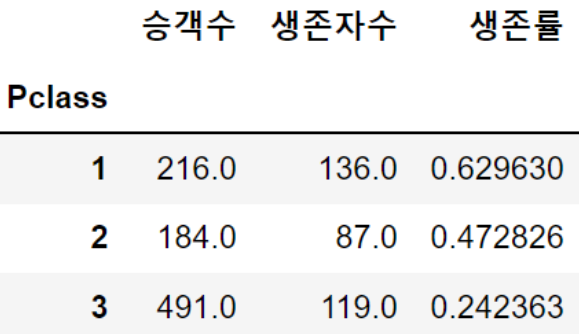

In [224]:
df.groupby('Pclass')[['Survived']]\
  .agg(["count", "sum", "mean"])['Survived']\
  .rename(columns={"count":"승객수", "sum":"생존자수", "mean":"생존율"})

,승객수,생존자수,생존율
Pclass,,,
1,216,136,0.629630
2,184,87,0.472826
3,491,119,0.242363


In [225]:
df.groupby('Pclass')['Survived'].agg(
    승객수='count',
    생존자수='sum',
    생존률='mean'
)

,승객수,생존자수,생존률
Pclass,,,
1,216,136,0.629630
2,184,87,0.472826
3,491,119,0.242363


In [226]:
# 커스텀 집계함수  : n(Series) -> 1

# 생존율(%) 계산
def survival_rate(series):
  return round(series.mean() * 100, 1)

# 최댓값과 최솟값의 차이(범위) 계산
def value_range(series):
  return series.max() - series.min()


df.groupby('Sex').agg(
    승객수=('Survived', 'count'),
    생존률=('Survived', survival_rate),
    나이범위=('Age', value_range),
)


,승객수,생존률,나이범위
Sex,,,
female,314,74.2,62.25
male,577,18.9,79.58


# sort_values(), sort_index()
값 기준 정렬, index 기준 정렬

In [227]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [228]:
# by=  정렬기준
#  컬럼명이나 컬럼들의 리스트
df.sort_values(by='Pclass')


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
857,858,1,1,"Daly, Mr. Peter Denis",male,51.0,0,0,113055,26.5500,E17,S
862,863,1,1,"Swift, Mrs. Frederick Joel (Margaret Welles Ba...",female,48.0,0,0,17466,25.9292,D17,S
867,868,0,1,"Roebling, Mr. Washington Augustus II",male,31.0,0,0,PC 17590,50.4958,A24,S
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
839,840,1,1,"Marechal, Mr. Pierre",male,NaN,0,0,11774,29.7000,C47,C
...,...,...,...,...,...,...,...,...,...,...,...,...
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


In [229]:
# 내림차순
df.sort_values(by='Pclass', ascending=False)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
853,854,1,1,"Lines, Miss. Mary Conover",female,16.0,0,1,PC 17592,39.4000,D28,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
30,31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,NaN,C


In [230]:
df.sort_values(by=['Pclass', 'Age'])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S
445,446,1,1,"Dodge, Master. Washington",male,4.00,0,2,33638,81.8583,A34,S
802,803,1,1,"Carter, Master. William Thornton II",male,11.00,1,2,113760,120.0000,B96 B98,S
435,436,1,1,"Carter, Miss. Lucile Polk",female,14.00,1,2,113760,120.0000,B96 B98,S
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [231]:
df.sort_values(by=['Pclass', 'Age'], ascending=[True, False])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [232]:
# sort_index() index 기준으로 정렬
df.sort_index(ascending=False)

# index 기준으로 내림차순

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [233]:
# 컬럼 이름 오름차순 정렬.
df.sort_index(axis=1)


,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket
0,22.0,NaN,S,7.2500,"Braund, Mr. Owen Harris",0,1,3,male,1,0,A/5 21171
1,38.0,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,female,1,1,PC 17599
2,26.0,NaN,S,7.9250,"Heikkinen, Miss. Laina",0,3,3,female,0,1,STON/O2. 3101282
3,35.0,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,female,1,1,113803
4,35.0,NaN,S,8.0500,"Allen, Mr. William Henry",0,5,3,male,0,0,373450
...,...,...,...,...,...,...,...,...,...,...,...,...
886,27.0,NaN,S,13.0000,"Montvila, Rev. Juozas",0,887,2,male,0,0,211536
887,19.0,B42,S,30.0000,"Graham, Miss. Margaret Edith",0,888,1,female,0,1,112053
888,NaN,NaN,S,23.4500,"Johnston, Miss. Catherine Helen ""Carrie""",2,889,3,female,1,0,W./C. 6607
889,26.0,C148,C,30.0000,"Behr, Mr. Karl Howell",0,890,1,male,0,1,111369


# pivot, pd.pivot_table 함수

In [234]:
df = pd.DataFrame({
    '지역': ['서울', '서울', '서울', '경기', '경기', '부산', '서울', '서울', '부산', '경기', '경기', '경기'],
    '요일': ['월요일', '화요일', '수요일', '월요일', '화요일', '월요일', '목요일', '금요일', '화요일', '수요일', '목요일', '금요일'],
    '강수량': [100, 80, 1000, 200, 200, 100, 50, 100, 200, 100, 50, 100],
    '강수확률': [80, 70, 90, 10, 20, 30, 50, 90, 20, 80, 50, 10]
                  })

df

,지역,요일,강수량,강수확률
0,서울,월요일,100,80
1,서울,화요일,80,70
2,서울,수요일,1000,90
3,경기,월요일,200,10
4,경기,화요일,200,20
5,부산,월요일,100,30
6,서울,목요일,50,50
7,서울,금요일,100,90
8,부산,화요일,200,20
9,경기,수요일,100,80


In [235]:
df.T


,0,1,2,3,4,5,6,7,8,9,10,11
지역,서울,서울,서울,경기,경기,부산,서울,서울,부산,경기,경기,경기
요일,월요일,화요일,수요일,월요일,화요일,월요일,목요일,금요일,화요일,수요일,목요일,금요일
강수량,100,80,1000,200,200,100,50,100,200,100,50,100
강수확률,80,70,90,10,20,30,50,90,20,80,50,10


## pivot()
 - dataframe의 형태를 변경
 - 인덱스, 컬럼, 데이터로 사용할 컬럼을 명시

In [ ]:
#  pivot(index=None, columns=None, values=None)

# index 로 지정할 컬럼
# column 으로 지정할 컬럼
# values 나머지 채울 값들.

In [ ]:
# 이제 지역별로(index)  요일별(column) 강수량/강수확률(value)을 보고싶다

In [236]:
df

,지역,요일,강수량,강수확률
0,서울,월요일,100,80
1,서울,화요일,80,70
2,서울,수요일,1000,90
3,경기,월요일,200,10
4,경기,화요일,200,20
5,부산,월요일,100,30
6,서울,목요일,50,50
7,서울,금요일,100,90
8,부산,화요일,200,20
9,경기,수요일,100,80


In [237]:
df.pivot(index='지역', columns='요일')


강수량                              강수확률                        
요일    금요일   목요일     수요일    월요일    화요일   금요일   목요일   수요일   월요일   화요일
지역                                                                 
경기  100.0  50.0   100.0  200.0  200.0  10.0  50.0  80.0  10.0  20.0
부산    NaN   NaN     NaN  100.0  200.0   NaN   NaN   NaN  30.0  20.0
서울  100.0  50.0  1000.0  100.0   80.0  90.0  50.0  90.0  80.0  70.0

In [ ]:
# ↑ 월~ 금 '요일' 이 두번 들어감.  강수량, 강수확률 <-- 2개의 컬럼이 있기 때문
# 부산 의 경우 금/목/수  데이터가 없다.

In [243]:
## 딱 한번만 실행!
df.loc[len(df)] = pd.Series(['경기', '금요일', 111, 11], index=['지역', '요일', '강수량', '강수확률'])
df

,지역,요일,강수량,강수확률
0,서울,월요일,100,80
1,서울,화요일,80,70
2,서울,수요일,1000,90
3,경기,월요일,200,10
4,경기,화요일,200,20
5,부산,월요일,100,30
6,서울,목요일,50,50
7,서울,금요일,100,90
8,부산,화요일,200,20
9,경기,수요일,100,80


In [241]:
# '지역', '요일' 이 같은 데이터가 중복되어 있으면 에러난다.!
df.pivot(index='지역', columns='요일')


ValueError: Index contains duplicate entries, cannot reshape

In [244]:
# 딱 한번만 실행!  아까 추가했던 마지막 row 제거
df.drop([len(df) - 1], inplace=True)
df

,지역,요일,강수량,강수확률
0,서울,월요일,100,80
1,서울,화요일,80,70
2,서울,수요일,1000,90
3,경기,월요일,200,10
4,경기,화요일,200,20
5,부산,월요일,100,30
6,서울,목요일,50,50
7,서울,금요일,100,90
8,부산,화요일,200,20
9,경기,수요일,100,80


In [245]:
# 거꾸로 해보자
df.pivot(index='요일', columns='지역')


강수량                 강수확률            
지역      경기     부산      서울    경기    부산    서울
요일                                         
금요일  100.0    NaN   100.0  10.0   NaN  90.0
목요일   50.0    NaN    50.0  50.0   NaN  50.0
수요일  100.0    NaN  1000.0  80.0   NaN  90.0
월요일  200.0  100.0   100.0  10.0  30.0  80.0
화요일  200.0  200.0    80.0  20.0  20.0  70.0

In [246]:
df.pivot(index='요일', columns='지역', values='강수량')

지역,경기,부산,서울
요일,,,
금요일,100.0,NaN,100.0
목요일,50.0,NaN,50.0
수요일,100.0,NaN,1000.0
월요일,200.0,100.0,100.0
화요일,200.0,200.0,80.0


In [248]:
df.pivot(index='요일', columns='지역')['강수량']

지역,경기,부산,서울
요일,,,
금요일,100.0,NaN,100.0
목요일,50.0,NaN,50.0
수요일,100.0,NaN,1000.0
월요일,200.0,100.0,100.0
화요일,200.0,200.0,80.0


## pd.pivot_table()
 - 기능적으로 pivot과 동일
 - pivot과의 차이점
   - 중복되는 모호한 값이 있을 경우, aggregation 함수 사용하여 값을 채움

In [249]:
df.pivot_table(df, index='지역', columns='요일')


강수량                              강수확률                        
요일    금요일   목요일     수요일    월요일    화요일   금요일   목요일   수요일   월요일   화요일
지역                                                                 
경기  100.0  50.0   100.0  200.0  200.0  10.0  50.0  80.0  10.0  20.0
부산    NaN   NaN     NaN  100.0  200.0   NaN   NaN   NaN  30.0  20.0
서울  100.0  50.0  1000.0  100.0   80.0  90.0  50.0  90.0  80.0  70.0

In [250]:
# 중복데이터를 만들어 본다.  서울-월요일
df2 = pd.DataFrame({
    '지역': ['서울', '서울', '서울', '경기', '경기', '부산', '서울', '서울', '부산', '경기', '경기', '경기'],
    '요일': ['월요일', '월요일', '수요일', '월요일', '화요일', '월요일', '목요일', '금요일', '화요일', '수요일', '목요일', '금요일'],
    '강수량': [100, 80, 1000, 200, 200, 100, 50, 100, 200, 100, 50, 100],
    '강수확률': [80, 70, 90, 10, 20, 30, 50, 90, 20, 80, 50, 10]
                  })

df2  # 서울 - 월요일 <-- 2개 있다.

,지역,요일,강수량,강수확률
0,서울,월요일,100,80
1,서울,월요일,80,70
2,서울,수요일,1000,90
3,경기,월요일,200,10
4,경기,화요일,200,20
5,부산,월요일,100,30
6,서울,목요일,50,50
7,서울,금요일,100,90
8,부산,화요일,200,20
9,경기,수요일,100,80


In [252]:
# df2.pivot(index='지역', columns='요일')

# df2.pivot_table?

In [ ]:
# pivot() 은 중복된 엔트리가 있으면 오류발생
# pivot_table() 은 중복된 엔트리는 aggfunc= 를 사용하여 새로운 값 대체
# aggfunc='mean'  (기본값)

In [253]:
# 서울, 월요일의 '평균값' 으로 채워진다. (디폴트)
df2.pivot_table(df2, index='지역', columns='요일', aggfunc='mean')


강수량                              강수확률                        
요일    금요일   목요일     수요일    월요일    화요일   금요일   목요일   수요일   월요일   화요일
지역                                                                 
경기  100.0  50.0   100.0  200.0  200.0  10.0  50.0  80.0  10.0  20.0
부산    NaN   NaN     NaN  100.0  200.0   NaN   NaN   NaN  30.0  20.0
서울  100.0  50.0  1000.0   90.0    NaN  90.0  50.0  90.0  75.0   NaN

In [254]:
df2.pivot_table(df2, index='지역', columns='요일', aggfunc='max')

강수량                              강수확률                        
요일    금요일   목요일     수요일    월요일    화요일   금요일   목요일   수요일   월요일   화요일
지역                                                                 
경기  100.0  50.0   100.0  200.0  200.0  10.0  50.0  80.0  10.0  20.0
부산    NaN   NaN     NaN  100.0  200.0   NaN   NaN   NaN  30.0  20.0
서울  100.0  50.0  1000.0  100.0    NaN  90.0  50.0  90.0  80.0   NaN

#  stack & unstack
 - stack : 컬럼 레벨에서 인덱스 레벨(row 레벨)로 dataframe 변경
  - 즉, 데이터를 쌓아올리는 개념으로 이해하면 쉬움
 - unstack : 인덱스 레벨에서 컬럼 레벨로 dataframe 변경
  - stack의 반대 operation

 - 둘은 역의 관계에 있음

In [255]:
df

,지역,요일,강수량,강수확률
0,서울,월요일,100,80
1,서울,화요일,80,70
2,서울,수요일,1000,90
3,경기,월요일,200,10
4,경기,화요일,200,20
5,부산,월요일,100,30
6,서울,목요일,50,50
7,서울,금요일,100,90
8,부산,화요일,200,20
9,경기,수요일,100,80


In [256]:
new_df = df.set_index(['지역', '요일'])
new_df

강수량  강수확률
지역 요일             
서울 월요일   100    80
   화요일    80    70
   수요일  1000    90
경기 월요일   200    10
   화요일   200    20
부산 월요일   100    30
서울 목요일    50    50
   금요일   100    90
부산 화요일   200    20
경기 수요일   100    80
   목요일    50    50
   금요일   100    10

In [ ]:
# unstack() : index(row) -> column

# unstack(level=-1, fill_value=None)
#   level : 인덱스의 레벨
#            new_df 의 경우 지역 의 인덱스 레벨이 0 이다
#                 -1 은 오른쪽 끝 인덱스 '요일' 이 컬럼이다.

In [257]:
# level=-1 (디폴트) 였던 '요일' index 가 '컬럼' 으로 올라간다
new_df.unstack()


강수량                              강수확률                        
요일    금요일   목요일     수요일    월요일    화요일   금요일   목요일   수요일   월요일   화요일
지역                                                                 
경기  100.0  50.0   100.0  200.0  200.0  10.0  50.0  80.0  10.0  20.0
부산    NaN   NaN     NaN  100.0  200.0   NaN   NaN   NaN  30.0  20.0
서울  100.0  50.0  1000.0  100.0   80.0  90.0  50.0  90.0  80.0  70.0

In [258]:
# level=0  인텍스가 컬럼으로 올라감
new_df.unstack(0)


강수량                 강수확률            
지역      경기     부산      서울    경기    부산    서울
요일                                         
금요일  100.0    NaN   100.0  10.0   NaN  90.0
목요일   50.0    NaN    50.0  50.0   NaN  50.0
수요일  100.0    NaN  1000.0  80.0   NaN  90.0
월요일  200.0  100.0   100.0  10.0  30.0  80.0
화요일  200.0  200.0    80.0  20.0  20.0  70.0

In [ ]:
# stack() : column -> index(row)
# stack(level=-1, dropna=True)
#         level : 컬럼의 레벨

In [259]:
df2 = new_df.unstack(0)
df2

강수량                 강수확률            
지역      경기     부산      서울    경기    부산    서울
요일                                         
금요일  100.0    NaN   100.0  10.0   NaN  90.0
목요일   50.0    NaN    50.0  50.0   NaN  50.0
수요일  100.0    NaN  1000.0  80.0   NaN  90.0
월요일  200.0  100.0   100.0  10.0  30.0  80.0
화요일  200.0  200.0    80.0  20.0  20.0  70.0

In [262]:
# level=0 의 컬럼 이 index 로 내려옴
df2.stack()


/tmp/ipykernel_1171/2460143265.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df2.stack()


강수량  강수확률
요일  지역              
금요일 경기   100.0  10.0
    서울   100.0  90.0
목요일 경기    50.0  50.0
    서울    50.0  50.0
수요일 경기   100.0  80.0
    서울  1000.0  90.0
월요일 경기   200.0  10.0
    부산   100.0  30.0
    서울   100.0  80.0
화요일 경기   200.0  20.0
    부산   200.0  20.0
    서울    80.0  70.0

In [263]:
df2.stack(-1)

/tmp/ipykernel_1171/391642428.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df2.stack(-1)


강수량  강수확률
요일  지역              
금요일 경기   100.0  10.0
    서울   100.0  90.0
목요일 경기    50.0  50.0
    서울    50.0  50.0
수요일 경기   100.0  80.0
    서울  1000.0  90.0
월요일 경기   200.0  10.0
    부산   100.0  30.0
    서울   100.0  80.0
화요일 경기   200.0  20.0
    부산   200.0  20.0
    서울    80.0  70.0

In [264]:
# 모든 컬럼을 다 내리면? (즉 컬럼이 없어지면) 결과는 -> Series
df2.stack().stack()


/tmp/ipykernel_1171/710730096.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df2.stack().stack()


요일   지역      
금요일  경기  강수량      100.0
         강수확률      10.0
     서울  강수량      100.0
         강수확률      90.0
목요일  경기  강수량       50.0
         강수확률      50.0
     서울  강수량       50.0
         강수확률      50.0
수요일  경기  강수량      100.0
         강수확률      80.0
     서울  강수량     1000.0
         강수확률      90.0
월요일  경기  강수량      200.0
         강수확률      10.0
     부산  강수량      100.0
         강수확률      30.0
     서울  강수량      100.0
         강수확률      80.0
화요일  경기  강수량      200.0
         강수확률      20.0
     부산  강수량      200.0
         강수확률      20.0
     서울  강수량       80.0
         강수확률      70.0
dtype: float64

In [265]:
new_df


강수량  강수확률
지역 요일             
서울 월요일   100    80
   화요일    80    70
   수요일  1000    90
경기 월요일   200    10
   화요일   200    20
부산 월요일   100    30
서울 목요일    50    50
   금요일   100    90
부산 화요일   200    20
경기 수요일   100    80
   목요일    50    50
   금요일   100    10

In [275]:
# [도전]
# 두 index 위치 (level)  변경하기
new_df.unstack(0).stack(-1)


/tmp/ipykernel_1171/321474016.py:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  new_df.unstack(0).stack()


강수량  강수확률
요일  지역              
금요일 경기   100.0  10.0
    서울   100.0  90.0
목요일 경기    50.0  50.0
    서울    50.0  50.0
수요일 경기   100.0  80.0
    서울  1000.0  90.0
월요일 경기   200.0  10.0
    부산   100.0  30.0
    서울   100.0  80.0
화요일 경기   200.0  20.0
    부산   200.0  20.0
    서울    80.0  70.0

# pd.concat()
DataFrame 병합

 - pandas.concat 함수
 - 축(axis)을 따라 dataframe을 병합 가능
   - axis = 0 → 행단위 병합 (디폴트)
   - axis = 1 → 열단위 병합

In [276]:
np.random.seed(42)
df1 = pd.DataFrame({'key1' : np.arange(10), 'value1' : np.random.randn(10)})
df2 = pd.DataFrame({'key1' : np.arange(10), 'value1' : np.random.randn(10)})

In [277]:
df1

,key1,value1
0,0,0.496714
1,1,-0.138264
2,2,0.647689
3,3,1.523030
4,4,-0.234153
5,5,-0.234137
6,6,1.579213
7,7,0.767435
8,8,-0.469474
9,9,0.542560


In [278]:
df2

,key1,value1
0,0,-0.463418
1,1,-0.465730
2,2,0.241962
3,3,-1.913280
4,4,-1.724918
5,5,-0.562288
6,6,-1.012831
7,7,0.314247
8,8,-0.908024
9,9,-1.412304


In [279]:
# 행 방향으로 병합 (axis=0)
pd.concat([df1, df2])


,key1,value1
0,0,0.496714
1,1,-0.138264
2,2,0.647689
3,3,1.523030
4,4,-0.234153
5,5,-0.234137
6,6,1.579213
7,7,0.767435
8,8,-0.469474
9,9,0.542560


In [280]:
# 열 방향 병합 (axis=1)
pd.concat([df1, df2], axis=1)


,key1,value1,key1,value1
0,0,0.496714,0,-0.463418
1,1,-0.138264,1,-0.465730
2,2,0.647689,2,0.241962
3,3,1.523030,3,-1.913280
4,4,-0.234153,4,-1.724918
5,5,-0.234137,5,-0.562288
6,6,1.579213,6,-1.012831
7,7,0.767435,7,0.314247
8,8,-0.469474,8,-0.908024
9,9,0.542560,9,-1.412304


### column /index 가 다른 경우

In [281]:
df3 = pd.DataFrame({'key2' : np.arange(10), 'value2' : np.random.randn(10)})
df3  # 컬럼명이 df1, df2 와는 다르다

,key2,value2
0,0,1.465649
1,1,-0.225776
2,2,0.067528
3,3,-1.424748
4,4,-0.544383
5,5,0.110923
6,6,-1.150994
7,7,0.375698
8,8,-0.600639
9,9,-0.291694


In [282]:
pd.concat([df1, df3])

,key1,value1,key2,value2
0,0.0,0.496714,NaN,NaN
1,1.0,-0.138264,NaN,NaN
2,2.0,0.647689,NaN,NaN
3,3.0,1.523030,NaN,NaN
4,4.0,-0.234153,NaN,NaN
5,5.0,-0.234137,NaN,NaN
6,6.0,1.579213,NaN,NaN
7,7.0,0.767435,NaN,NaN
8,8.0,-0.469474,NaN,NaN
9,9.0,0.542560,NaN,NaN


# pd.merge() , join()
데이터프레임 병합과 조인


## dataframe merge
 - SQL의 join처럼 특정한 column을 기준으로 병합
   - join 방식: how 파라미터를 통해 명시
     - inner: 기본값, 일치하는 값이 있는 경우
     - left: left outer join
     - right: right outer join
     - outer: full outer join
     
 - pandas.merge 함수가 사용됨


In [283]:
customer = pd.DataFrame({'customer_id' : np.arange(6),
                    'name' : ['철수'"", '영희', '길동', '영수', '수민', '동건'],
                    '나이' : [40, 20, 21, 30, 31, 18]})

customer


,customer_id,name,나이
0,0,철수,40
1,1,영희,20
2,2,길동,21
3,3,영수,30
4,4,수민,31
5,5,동건,18


In [284]:
orders = pd.DataFrame({'customer_id' : [1, 1, 2, 2, 2, 3, 3, 1, 4, 9],
                    'item' : ['치약', '칫솔', '이어폰', '헤드셋', '수건', '생수', '수건', '치약', '생수', '케이스'],
                    'quantity' : [1, 2, 1, 1, 3, 2, 2, 3, 2, 1]})
orders


,customer_id,item,quantity
0,1,치약,1
1,1,칫솔,2
2,2,이어폰,1
3,2,헤드셋,1
4,2,수건,3
5,3,생수,2
6,3,수건,2
7,1,치약,3
8,4,생수,2
9,9,케이스,1


In [285]:
pd.merge(customer, orders, on='customer_id')

# customer_id 컬럼을 기준으로 merge 됨.
# customer_id 컬럼은 한번만 등장 (마치 Natural join)


# customer 테이블에 있었던 '동건' '철수' 은 안보인다.
# orders 테이블에  9번 customer 가 주문한 내용도 빠졌다.
# 왜?  merge 조건에서 빠졌다.
# 기본적으로 inner join 이기에 조건에 맞지 않으면 빠지는 거다  (how="inner") (디폴트)

,customer_id,name,나이,item,quantity
0,1,영희,20,치약,1
1,1,영희,20,칫솔,2
2,1,영희,20,치약,3
3,2,길동,21,이어폰,1
4,2,길동,21,헤드셋,1
5,2,길동,21,수건,3
6,3,영수,30,생수,2
7,3,영수,30,수건,2
8,4,수민,31,생수,2


In [286]:
pd.merge(customer, orders, on='customer_id', how='left')

,customer_id,name,나이,item,quantity
0,0,철수,40,NaN,NaN
1,1,영희,20,치약,1.0
2,1,영희,20,칫솔,2.0
3,1,영희,20,치약,3.0
4,2,길동,21,이어폰,1.0
5,2,길동,21,헤드셋,1.0
6,2,길동,21,수건,3.0
7,3,영수,30,생수,2.0
8,3,영수,30,수건,2.0
9,4,수민,31,생수,2.0


In [288]:
pd.merge(customer, orders, on='customer_id', how='right')

,customer_id,name,나이,item,quantity
0,1,영희,20.0,치약,1
1,1,영희,20.0,칫솔,2
2,2,길동,21.0,이어폰,1
3,2,길동,21.0,헤드셋,1
4,2,길동,21.0,수건,3
5,3,영수,30.0,생수,2
6,3,영수,30.0,수건,2
7,1,영희,20.0,치약,3
8,4,수민,31.0,생수,2
9,9,NaN,NaN,케이스,1


In [ ]:
pd.merge(customer, orders, on='customer_id', how='outer')  # outer = left U right

## index 기준으로 merge 하기

In [ ]:
# pd.merge(
#     left,
#     right,
#     how: str = 'inner',
#     on=None,
#     left_on=None,
#     right_on=None,
#     left_index: bool = False,   <-- merge 기준이 index 인지 여부
#     right_index: bool = False,  <-- merge 기준이 index 인지 여부
#     sort: bool = False,
#     suffixes=('_x', '_y'),
#     copy: bool = True,
#     indicator: bool = False,
#     validate=None,
# ) -> 'DataFrame'

In [289]:
cust1 = customer.set_index('customer_id')
cust1

,name,나이
customer_id,,
0,철수,40
1,영희,20
2,길동,21
3,영수,30
4,수민,31
5,동건,18


In [290]:
order1 = orders.set_index('customer_id')
order1

,item,quantity
customer_id,,
1,치약,1
1,칫솔,2
2,이어폰,1
2,헤드셋,1
2,수건,3
3,생수,2
3,수건,2
1,치약,3
4,생수,2


In [291]:
pd.merge(cust1, order1, left_index=True, right_index=True)

,name,나이,item,quantity
customer_id,,,,
1,영희,20,치약,1
1,영희,20,칫솔,2
1,영희,20,치약,3
2,길동,21,이어폰,1
2,길동,21,헤드셋,1
2,길동,21,수건,3
3,영수,30,생수,2
3,영수,30,수건,2
4,수민,31,생수,2


## 도전] 가장 많이 팔린 아이템은?
  - 수건 5

In [356]:
orders.groupby('item')['quantity'].agg('sum').sort_values(ascending=False).head(1)



,quantity
item,
수건,5


## 도전] 영희가 가장 많이 구매한 아이템은?
  - 치약 4

In [384]:
result = pd.merge(customer, orders, on='customer_id')
result[result['name'] == '영희'].groupby('item')['quantity'].sum().sort_values(ascending=False).head(1)

,quantity
item,
치약,4


## join() 함수
 - 내부적으로 pd.merge 함수 사용
 - 기본적으로 index를 사용하여 left join (디폴트)

In [386]:
cust1

,name,나이
customer_id,,
0,철수,40
1,영희,20
2,길동,21
3,영수,30
4,수민,31
5,동건,18


In [388]:
order1

,item,quantity
customer_id,,
1,치약,1
1,칫솔,2
2,이어폰,1
2,헤드셋,1
2,수건,3
3,생수,2
3,수건,2
1,치약,3
4,생수,2


In [389]:
cust1.join(order1)  # left join 수행 (기본)

,name,나이,item,quantity
customer_id,,,,
0,철수,40,NaN,NaN
1,영희,20,치약,1.0
1,영희,20,칫솔,2.0
1,영희,20,치약,3.0
2,길동,21,이어폰,1.0
2,길동,21,헤드셋,1.0
2,길동,21,수건,3.0
3,영수,30,생수,2.0
3,영수,30,수건,2.0


In [390]:
cust1.join(order1, how='inner')

,name,나이,item,quantity
customer_id,,,,
1,영희,20,치약,1
1,영희,20,칫솔,2
1,영희,20,치약,3
2,길동,21,이어폰,1
2,길동,21,헤드셋,1
2,길동,21,수건,3
3,영수,30,생수,2
3,영수,30,수건,2
4,수민,31,생수,2
